<a href="https://colab.research.google.com/github/mailinh21042005-rgb/Rice-leaf-disease/blob/main/Rice%20leaf%20disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



### ===== Cell 1:  Install & Imports =====


In [ ]:
# ===== Cell 1: Install & Imports =====
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image
from google.colab import data_table
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import joblib  # for loading saved features (if used)
import warnings
warnings.filterwarnings('ignore')

# model:
from sklearn.svm import SVC


# Lấy địa chỉ từ file đã up lên drive ở chế công khai ---------------------------------------------
# địa chỉ đường dẫn: https://drive.google.com/file/d/"FILE_ID"
FILE_ID = "1RmJbTZ1bPP7JvKomxG4Yp5QhxH5KsTRM"

# khai báo hàm con dùng để mở file
def download_dataset(file_id):
    if os.path.exists("data_downloaded.zip"):
        os.remove("data_downloaded.zip")
    print(f">>> Đang tải dữ liệu từ ID: {file_id} ...")

# đoạn code có thể gây lỗi
    try:
        os.system("pip install --upgrade --quiet gdown")
        exit_code = os.system(f'gdown --id {file_id} -O data_downloaded.zip --fuzzy')

        # Kiểm tra file
        if os.path.exists("data_downloaded.zip") and os.path.getsize("data_downloaded.zip") > 1000:
            print(">>> Tải xong! Đang giải nén...")
            with zipfile.ZipFile("data_downloaded.zip", 'r') as zip_ref:
                zip_ref.extractall("dataset_folder")
            print(">>> Giải nén thành công!")
            return True
        else:
            print("XXX LỖI: Tải thất bại (File quá nhỏ hoặc không tồn tại).")
            print("=> Hãy kiểm tra lại quyền chia sẻ 'Anyone with the link' của file.")
            return False

#xử lý khi lỗi xãy ra (in báo lỗi)
    except Exception as e:
        print(f"Lỗi hệ thống: {e}")
        return False

# ---------------------------------------------------------------------------------------------------
if download_dataset(FILE_ID):
    data = []
    metadata = []
    class_names = []

    root = "dataset_folder"
    print(f"\n>>> Đang quét ảnh trong thư mục giải nén...")

    for current_path, dirs, files in os.walk(root):
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        if len(images) > 0:
            folder_name = os.path.basename(current_path)

            if folder_name.startswith(".") or folder_name.startswith("__"):
                continue

            if folder_name not in class_names:
                class_names.append(folder_name)

            class_idx = class_names.index(folder_name)

            for fname in images:
                try:
                    fpath = os.path.join(current_path, fname)
                    # Đọc ảnh
                    img = Image.open(fpath)
                    arr = np.array(img)

                    data.append(arr)
                    metadata.append({
                        "File Name": fname,
                        "Class Name": folder_name,
                        "Label ID": class_idx
                    })
                except:
                    pass

# In kết quả
    # data = np.array(data)

    if len(data) > 0:
        print(f"\n=> TỔNG SỐ ẢNH TÌM THẤY: {len(data)}")

        df = pd.DataFrame(metadata)
        df = df.sort_values("Class Name") # Sắp xếp theo tên lớp
    else:
        print("❌ Cảnh báo: File zip giải nén thành công nhưng không tìm thấy ảnh nào bên trong.")

>>> Đang tải dữ liệu từ ID: 1RmJbTZ1bPP7JvKomxG4Yp5QhxH5KsTRM ...
>>> Tải xong! Đang giải nén...
>>> Giải nén thành công!

>>> Đang quét ảnh trong thư mục giải nén...

=> TỔNG SỐ ẢNH TÌM THẤY: 120


### ===== Cell 2: mô tả dữ liệu =====


In [ ]:
# ===== Cell 2: Load built-in Wine dataset (no download needed) =====
# Mô tả dữ liệu
if len(metadata) > 0:
    # Tạo DataFrame từ metadata
    df = pd.DataFrame(metadata)

    # Nội dung giải thích ý nghĩa
    meaning_text = (
        "Dữ liệu gồm 3 loại bệnh lúa chính:\n"
        "1. Bacterial leaf blight: Bệnh cháy bìa lá (Bạc lá) do vi khuẩn.\n"
        "2. Brown spot: Bệnh đốm nâu do nấm.\n"
        "3. Leaf smut: Bệnh than đen (đen lép hạt) do nấm."
    )

    # Chuẩn bị dữ liệu cho bảng
    desc_data = {
        "Mô tả dữ liệu (Criteria)": [
            "Số mẫu (Rows)",
            "Số thuộc tính (Columns)",
            "Tên biến mục tiêu (Label)",
            "Loại dữ liệu",
            "Số lượng lớp (Classes)",
            "Danh sách các lớp",
            "Giải thích ý nghĩa các lớp"
        ],
        "Giá trị (Values)": [
            f"{len(df)} ảnh",
            f"{("Height, Width, Channels")}",
            "Class Name",
            "Image",
            f"{len(class_names)} lớp",
            ", ".join(class_names),
            meaning_text
        ]
    }

    df_desc = pd.DataFrame(desc_data)

    print("\n" + "="*40)
    print(">>> BẢNG MÔ TẢ DỮ LIỆU")
    print("="*40)

    # Định dạng bảng: Ẩn index, căn lề trái, xuống dòng tự động
    styled_table = df_desc.style.hide(axis='index').set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'vertical-align': 'top'
    })

    # Hiển thị bảng
    display(styled_table)

else:
    print("❌ Cảnh báo: File zip giải nén thành công nhưng không tìm thấy ảnh nào bên trong.")


>>> BẢNG MÔ TẢ DỮ LIỆU


Mô tả dữ liệu (Criteria),Giá trị (Values)
Số mẫu (Rows),120 ảnh
Số thuộc tính (Columns),"Height, Width, Channels"
Tên biến mục tiêu (Label),Class Name
Loại dữ liệu,Image
Số lượng lớp (Classes),3 lớp
Danh sách các lớp,"Leaf smut, Brown spot, Bacterial leaf blight"
Giải thích ý nghĩa các lớp,Dữ liệu gồm 3 loại bệnh lúa chính: 1. Bacterial leaf blight: Bệnh cháy bìa lá (Bạc lá) do vi khuẩn. 2. Brown spot: Bệnh đốm nâu do nấm. 3. Leaf smut: Bệnh than đen (đen lép hạt) do nấm.


### ===== Cell 3: EDA =====



>>> KIỂM TRA DỮ LIỆU THÔ

[A] Bảng kiểm tra Missing Values:


,Số lượng Missing,Tỷ lệ (%)
File Name,0,0.0
Class Name,0,0.0
Label ID,0,0.0
Width,0,0.0
Height,0,0.0
Mean Intensity,0,0.0



[B] Biểu đồ Outliers (Boxplot):


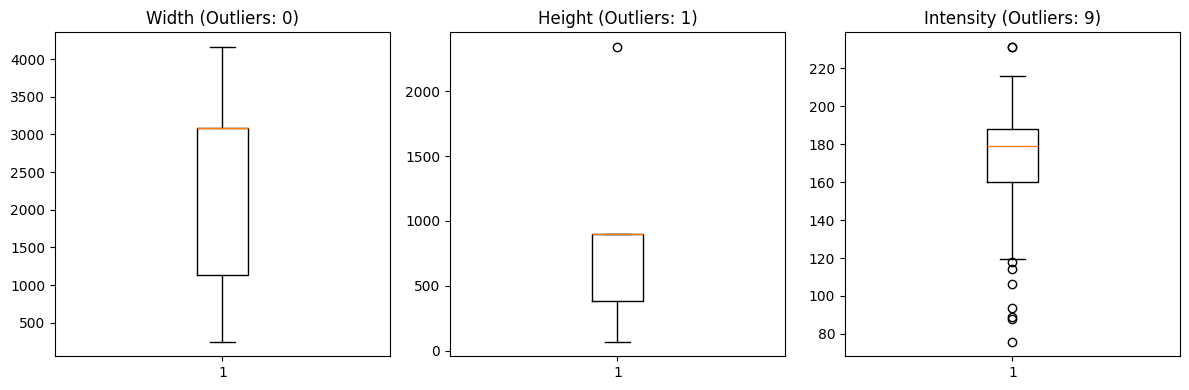


[C] KẾT LUẬN:
   o "Dataset có 0 dòng bị thiếu (missing values)."
   o "Có 1 giá trị ngoại lai ở thuộc tính 'Height' (Chiều dài ảnh không đồng nhất)."
   o "Có 9 giá trị ngoại lai ở thuộc tính 'Mean Intensity' (Ảnh quá sáng/tối)."
   o "Có 0 dòng trùng lặp đã được phát hiện."


In [ ]:
# ===== Cell 3: Quick EDA =====
# Kiểm tra dữ liệu thô

print("\n" + "="*40)
print(">>> KIỂM TRA DỮ LIỆU THÔ")
print("="*40)

if len(data) > 0:
    widths = [img.shape[1] for img in data]      # Chiều rộng
    heights = [img.shape[0] for img in data]     # Chiều cao
    intensities = [img.mean() for img in data]   # Độ sáng trung bình

    # Thêm vào DataFrame hiện tại
    df['Width'] = widths
    df['Height'] = heights
    df['Mean Intensity'] = intensities

    # Kiểm tra missing values --------------------------------------------------
    print("\n[A] Bảng kiểm tra Missing Values:")
    missing_df = pd.DataFrame(df.isnull().sum(), columns=['Số lượng Missing'])
    missing_df['Tỷ lệ (%)'] = (missing_df['Số lượng Missing'] / len(df)) * 100
    display(missing_df)

    # Kiểm tra duplicate rows (cột bị trùng)
    duplicate_count = df.duplicated(subset=['File Name', 'Width', 'Height']).sum()

    # Kiểm tra outliers bằng IQR
    def count_outliers_iqr(dataframe, column):
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Đếm số lượng giá trị nằm ngoài khoảng
        n_outliers = ((dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)).sum()
        return n_outliers

    outlier_w = count_outliers_iqr(df, 'Width')
    outlier_h = count_outliers_iqr(df, 'Height')
    outlier_i = count_outliers_iqr(df, 'Mean Intensity')

    # Vẽ biểu đồ Boxplot để chỉ ra Outliers ------------------------------------
    print("\n[B] Biểu đồ Outliers (Boxplot):")
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.boxplot(df['Width'])
    plt.title(f'Width (Outliers: {outlier_w})')

    plt.subplot(1, 3, 2)
    plt.boxplot(df['Height'])
    plt.title(f'Height (Outliers: {outlier_h})')

    plt.subplot(1, 3, 3)
    plt.boxplot(df['Mean Intensity'])
    plt.title(f'Intensity (Outliers: {outlier_i})')

    plt.tight_layout()
    plt.show()

    # Kết luận -----------------------------------------------------------------
    print("\n[C] KẾT LUẬN:")

    # 1. Kết luận Missing
    total_missing = df.isnull().sum().sum()
    print(f"   o \"Dataset có {total_missing} dòng bị thiếu (missing values).\"")

    # 2. Kết luận Outliers
    if outlier_w > 0:
        print(f"   o \"Có {outlier_w} giá trị ngoại lai ở thuộc tính 'Width' (Chiều rộng ảnh không đồng nhất).\"")
    if outlier_h > 0:
        print(f"   o \"Có {outlier_h} giá trị ngoại lai ở thuộc tính 'Height' (Chiều dài ảnh không đồng nhất).\"")
    if outlier_i > 0:
        print(f"   o \"Có {outlier_i} giá trị ngoại lai ở thuộc tính 'Mean Intensity' (Ảnh quá sáng/tối).\"")
    if outlier_w == 0 and outlier_h == 0 and outlier_i == 0:
        print(f"   o \"Không phát hiện giá trị ngoại lai đáng kể theo phương pháp IQR.\"")

    # 3. Kết luận Duplicate
    print(f"   o \"Có {duplicate_count} dòng trùng lặp đã được phát hiện.\"")

else:
    print("Chưa có dữ liệu để kiểm tra.")

### ===== Cell 4: Thống kê mô tả =====


In [ ]:
# ===== Cell 4: STATISTICS =====
# Thống kê mô tả
print("\n" + "="*40)
print(">>> THỐNG KÊ MÔ TẢ (STATISTICS)")
print("="*40)

if len(data) > 0:
    print("\n[A] Bảng thống kê kích thước ảnh:")

    # Lấy thống kê mô tả cho 2 cột kích thước
    stats_df = df[['Width', 'Height']].describe().drop(['count']).round(2)

    # Thêm thông tin về tỷ lệ khung hình (Aspect Ratio)
    df['Aspect Ratio'] = df['Width'] / df['Height']
    stats_aspect = df['Aspect Ratio'].describe().round(2)

    # Hiển thị bảng thống kê Width/Height
    display(stats_df)

    # Tính toán tỷ lệ các lớp
    class_dist = df['Class Name'].value_counts(normalize=True) * 100
    class_counts = df['Class Name'].value_counts()

    print("\n[B] Tỉ lệ phân bố dữ liệu từng lớp:")
    dist_df = pd.DataFrame({
        'Số lượng': class_counts,
        'Tỷ lệ (%)': class_dist.round(2)
    })
    display(dist_df)

    # Kiểm tra color depth
    sample_img_mode = "RGB" if data[0].ndim == 3 else "Grayscale"
    color_depth_desc = "24-bit (8-bit per channel)" if sample_img_mode == "RGB" else "8-bit"

    # Mô tả xu hướng
    print("\n[C] Mô tả xu hướng và Kết luận:")

    conclusions = []

    # a. Nhận xét về độ đồng nhất kích thước
    std_w = stats_df.loc['std', 'Width']
    std_h = stats_df.loc['std', 'Height']

    if std_w > 0 or std_h > 0:
        desc_size = (
            f"Ảnh có kích thước KHÔNG đồng nhất.\n"
            f"      (Độ lệch chuẩn Width: {std_w}, Height: {std_h}).\n"
            f"      => Cần thực hiện Resize ảnh về kích thước cố định (ví dụ: 224x224) ở bước Tiền xử lý."
        )
    else:
        desc_size = f"Ảnh có kích thước đồng nhất ({stats_df.loc['mean', 'Width']}x{stats_df.loc['mean', 'Height']}). Không cần resize."
    conclusions.append(desc_size)

    # b. Nhận xét về phân bố lớp
    max_ratio = class_dist.max()
    min_ratio = class_dist.min()
    if (max_ratio - min_ratio) > 20: # Nếu lệch nhau quá 20%
        desc_class = f"Dữ liệu mất cân bằng (Imbalanced). Lớp chiếm nhiều nhất là {class_dist.idxmax()} ({max_ratio:.1f}%)."
    else:
        desc_class = "Dữ liệu phân bố đồng đều giữa các lớp."
    conclusions.append(desc_class)

    # c. Nhận xét Color Depth
    conclusions.append(f"Color Depth: {color_depth_desc} ({sample_img_mode}).")

    # In các dòng kết luận
    for item in conclusions:
        print(f"   o \"{item}\"")

else:
    print("Chưa có dữ liệu.")


>>> THỐNG KÊ MÔ TẢ (STATISTICS)

[A] Bảng thống kê kích thước ảnh:


,Width,Height
mean,2398.44,721.34
std,1130.49,344.26
min,250.00,71.00
25%,1137.00,380.00
50%,3081.00,897.00
75%,3081.00,897.00
max,4160.00,2340.00



[B] Tỉ lệ phân bố dữ liệu từng lớp:


,Số lượng,Tỷ lệ (%)
Class Name,,
Leaf smut,40,33.33
Brown spot,40,33.33
Bacterial leaf blight,40,33.33



[C] Mô tả xu hướng và Kết luận:
   o "Ảnh có kích thước KHÔNG đồng nhất.
      (Độ lệch chuẩn Width: 1130.49, Height: 344.26).
      => Cần thực hiện Resize ảnh về kích thước cố định (ví dụ: 224x224) ở bước Tiền xử lý."
   o "Dữ liệu phân bố đồng đều giữa các lớp."
   o "Color Depth: 24-bit (8-bit per channel) (RGB)."


### ===== Cell 5: Trực quan =====



>>> BIỂU ĐỒ & NHẬN XÉT

[A] Grid 3x3 Ảnh mẫu (Đại diện từng lớp):


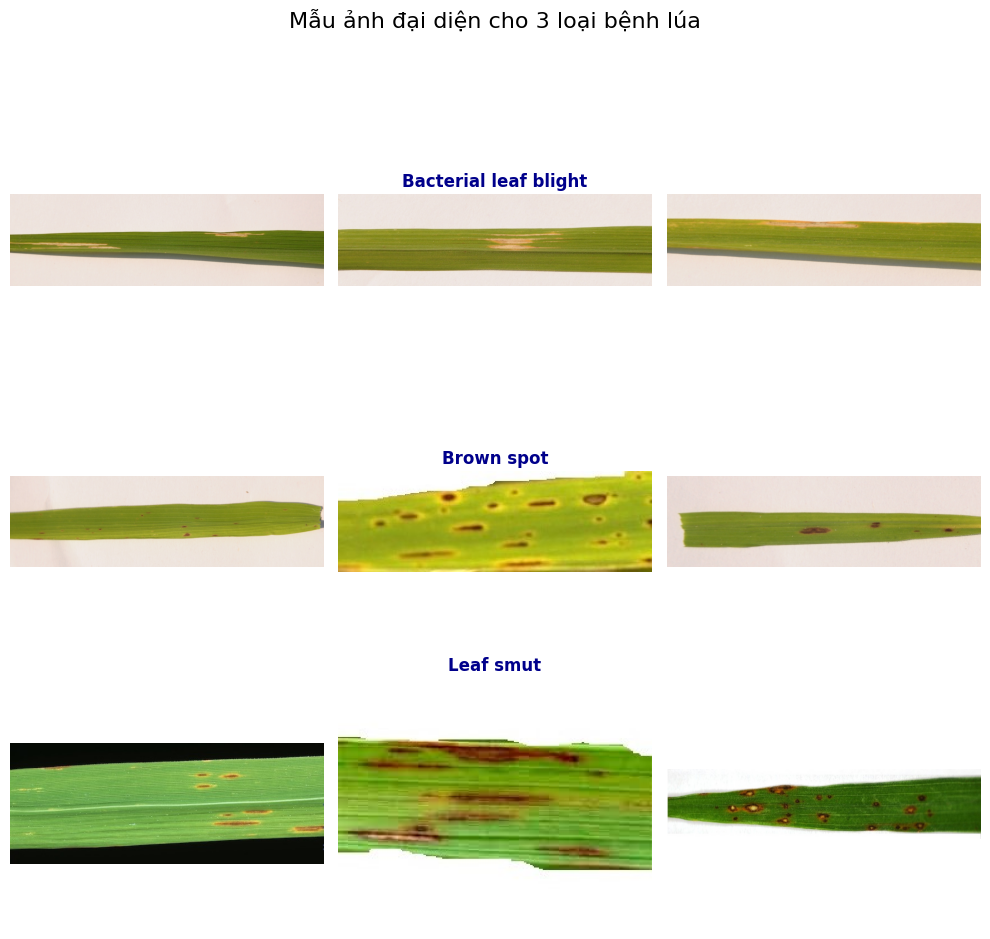


[B] Biểu đồ phân bố số lượng ảnh:


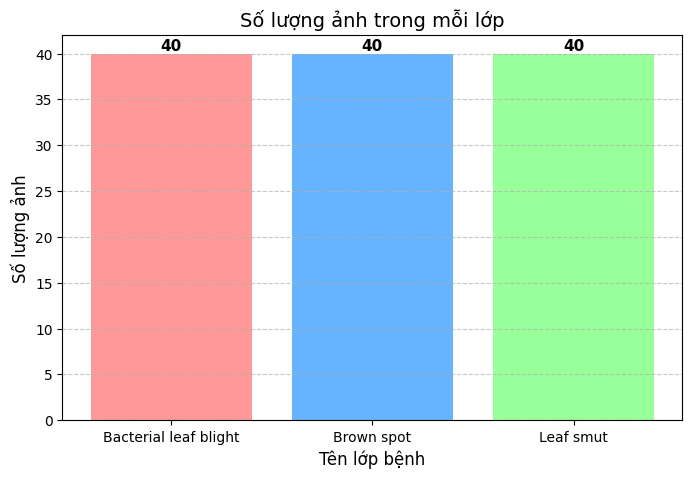


[C] Nhận xét: 
   o "Ảnh không đồng nhất về kích thước -> cần resize về 224x224."


In [ ]:
# ===== Cell 5:  =====
# Trực quan hóa và Nhận xét
print("\n" + "="*40)
print(">>> BIỂU ĐỒ & NHẬN XÉT")
print("="*40)

if len(data) > 0:
    # Vẽ Grid 3x3 ảnh mẫu
    print("\n[A] Grid 3x3 Ảnh mẫu (Đại diện từng lớp):")

    unique_classes = sorted(df['Class Name'].unique())

    # Tạo khung vẽ 3 hàng x 3 cột
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle('Mẫu ảnh đại diện cho 3 loại bệnh lúa', fontsize=16)

    for i, c_name in enumerate(unique_classes):
        # Lấy index của 3 ảnh đầu tiên thuộc lớp này
        subset_indices = df[df['Class Name'] == c_name].index[:3]

        for j, idx in enumerate(subset_indices):
            if i < 3 and j < 3: # Đảm bảo không vượt quá lưới 3x3
                img_arr = data[idx]
                ax = axes[i, j]
                ax.imshow(img_arr)

                # Chỉ hiện tên lớp ở cột đầu tiên của mỗi hàng
                if j == 1:
                    ax.set_title(c_name, fontsize=12, fontweight='bold', color='darkblue')

                ax.axis('off') # Tắt trục tọa độ cho đẹp

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Chừa chỗ cho tiêu đề lớn
    plt.show()

    # Biểu đồ cột số lượng ảnh mỗi lớp
    print("\n[B] Biểu đồ phân bố số lượng ảnh:")

    class_counts = df['Class Name'].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    bars = plt.bar(class_counts.index, class_counts.values, color=['#ff9999','#66b3ff','#99ff99'])

    plt.title('Số lượng ảnh trong mỗi lớp', fontsize=14)
    plt.xlabel('Tên lớp bệnh', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Hiển thị số liệu cụ thể trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.show()

    # Nhận xét kết quả
    print("\n[C] Nhận xét: ")

    # Kiểm tra độ lệch chuẩn của kích thước ảnh
    std_w = df['Width'].std()
    std_h = df['Height'].std()

    # In ra câu nhận xét
    conclusion_text = ""
    if std_w > 0 or std_h > 0:
        conclusion_text = "Ảnh không đồng nhất về kích thước -> cần resize về 224x224."
    else:
        input_shape = f"{df['Width'].iloc[0]}x{df['Height'].iloc[0]}"
        conclusion_text = f"Ảnh đã đồng nhất kích thước ({input_shape})."

    # In ra câu kết luận in nghiêng
    print(f"   o \"{conclusion_text}\"")

else:
    print("Chưa có dữ liệu để vẽ biểu đồ.")

### ===== Cell 6: Resize picture =====


In [ ]:
# ===== Cell 8: Resize picture =====
from skimage.feature import hog
from skimage import exposure, color
from skimage.transform import resize

# Hàm trích xuất đặc trưng cho 1 ảnh
def extract_features(img_path):
    try:
        # 1. Đọc ảnh và Resize
        if not os.path.exists(img_path): return None
        img = Image.open(img_path).convert('RGB')
        img = img.resize((128, 128)) # Resize về chuẩn
        img_np = np.array(img)

        # 2. ĐẶC TRƯNG MÀU SẮC (Color Histogram)
        # Tính histogram cho 3 kênh R, G, B (mỗi kênh 32 bins)
        # Ý nghĩa: Đếm xem có bao nhiêu điểm ảnh màu đỏ đậm, đỏ nhạt, xanh...
        h_r, _ = np.histogram(img_np[:,:,0], bins=32, range=(0, 256))
        h_g, _ = np.histogram(img_np[:,:,1], bins=32, range=(0, 256))
        h_b, _ = np.histogram(img_np[:,:,2], bins=32, range=(0, 256))
        # Chuẩn hóa histogram để tổng bằng 1 (tránh ảnh to ảnh nhỏ ảnh hưởng)
        color_feat = np.hstack([h_r, h_g, h_b])
        color_feat = color_feat / (color_feat.sum() + 1e-7)

        # 3. ĐẶC TRƯNG HÌNH DẠNG (HOG)
        # Chuyển sang ảnh xám để tính HOG
        gray = color.rgb2gray(img_np)
        # pixels_per_cell=(16, 16) giúp giảm số chiều dữ liệu so với pixel thô
        hog_feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(4, 4), block_norm='L2-Hys', visualize=False)

        # 4. KẾT HỢP (Concatenate)
        # Nối đuôi 2 vector lại thành 1 vector đặc trưng duy nhất
        final_feature = np.hstack([color_feat, hog_feat])
        return final_feature

    except Exception as e:
        print(f"Lỗi xử lý ảnh {img_path}: {e}")
        return None

print(">>> Đã định nghĩa hàm trích xuất đặc trưng (Color + HOG).")

>>> Đã định nghĩa hàm trích xuất đặc trưng (Color + HOG).




### ===== Cell 7: loại bỏ OUTLINERS =====



>>> XỬ LÝ OUTLIERS (INTENSITY)
- Số lượng mẫu ban đầu: 120
- Số lượng mẫu sau khi xử lý: 111
- Số lượng Outliers đã loại bỏ: 9
=> Hình ảnh các mẫu bị loại bỏ (Quá tối hoặc quá sáng):


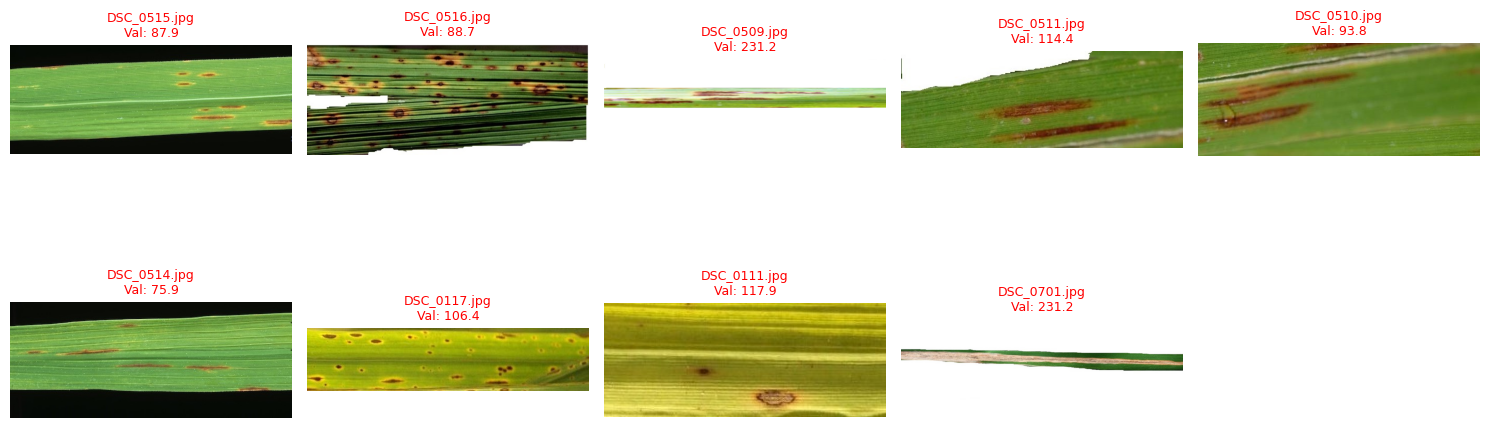

In [ ]:
# Xử lý giá trị ngoại lai (Outliers)
print("\n" + "="*40)
print(">>> XỬ LÝ OUTLIERS (INTENSITY)")
print("="*40)

if len(data) > 0 and 'Mean Intensity' in df.columns:

    # 1. Tính toán IQR cho Mean Intensity
    Q1 = df['Mean Intensity'].quantile(0.25)
    Q3 = df['Mean Intensity'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Thực hiện lọc dữ liệu
    # Giữ lại những dòng nằm trong khoảng an toàn
    df_clean = df[(df['Mean Intensity'] >= lower_bound) & (df['Mean Intensity'] <= upper_bound)]

    # Các dòng bị loại bỏ
    outliers_removed = df[~((df['Mean Intensity'] >= lower_bound) & (df['Mean Intensity'] <= upper_bound))]

    num_removed = len(df) - len(df_clean)

    print(f"- Số lượng mẫu ban đầu: {len(df)}")
    print(f"- Số lượng mẫu sau khi xử lý: {len(df_clean)}")
    print(f"- Số lượng Outliers đã loại bỏ: {num_removed}")

    if num_removed > 0:
        print("=> Hình ảnh các mẫu bị loại bỏ (Quá tối hoặc quá sáng):")

        num_show = num_removed # 1. Lấy hết số lượng outlier
        cols = 5
        rows = (num_show // cols) + (1 if num_show % cols > 0 else 0)
        plt.figure(figsize=(15, 3 * rows))
        outlier_indices = outliers_removed.index

        for i, idx in enumerate(outlier_indices):
            try:
                img_arr = data[idx]
                file_name = df.loc[idx, 'File Name']
                intensity = df.loc[idx, 'Mean Intensity']

                plt.subplot(rows, cols, i + 1)
                plt.imshow(img_arr)
                plt.title(f"{file_name}\nVal: {intensity:.1f}", fontsize=9, color='red')
                plt.axis('off')
            except:
                pass

        plt.tight_layout()
        plt.show()
        # -------------------------------------------------

    else:
        print("=> Dữ liệu tốt, không cần loại bỏ mẫu nào.")


else:
    print("Chưa có thông tin Intensity để xử lý.")

### ===== Cell 8: Chia mẫu Train/Test =====


In [ ]:
# ===== Cell 7: data Train/ data test =====

if len(data) > 0:
    # Cấu hình
    IMG_SIZE = (128, 128)
    BASE_DIR = "data/processed"
    IMG_DIR = os.path.join(BASE_DIR, "images") # Folder chứa ảnh vật lý

    # Reset thư mục
    if os.path.exists(BASE_DIR): shutil.rmtree(BASE_DIR)
    os.makedirs(IMG_DIR)

    # Chia tách dữ liệu
    # 1. Tách 80% Train - 20% Temp (Val+Test)

if 'df_clean' in locals():
    data_to_split = df_clean
    print(">>> Đang sử dụng dữ liệu đã làm sạch (df_clean).")
else:
    data_to_split = df
    print(">>> Cảnh báo: Không tìm thấy df_clean, đang dùng dữ liệu gốc.")

train_df, temp_df = train_test_split(data_to_split, test_size=0.2, stratify=data_to_split['Class Name'], random_state=42)

    # 2. Tách 20% Temp -> 10% Val - 10% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['Class Name'], random_state=42)

print(f"   - Train: {len(train_df)} mẫu")
print(f"   - Val:   {len(val_df)} mẫu")
print(f"   - Test:  {len(test_df)} mẫu")
print(f"   => “Dữ liệu được tách theo random_state = 42 để đảm bảo tái lặp.”")
    # Xử lý ảnh
    # Map đường dẫn file gốc
file_path_map = {}
for root_dir, _, files in os.walk("dataset_folder"):
    for f in files: file_path_map[f] = os.path.join(root_dir, f)

def process_and_get_info(dataframe, subset_name):
    processed_data = []

    print(f"Processing {subset_name} subset...") # Added for debugging
    for idx, row in dataframe.iterrows():
        fname = row['File Name']
        label = row['Label ID']

        if fname in file_path_map:
            try:
                # Đọc ảnh gốc
                img = Image.open(file_path_map[fname]).convert('RGB')

                # 1. RESIZE về 128x128
                img = img.resize(IMG_SIZE)

                # 2. Lưu ảnh xuống đĩa (thêm suffix tên tập để tránh trùng tên file)
                save_name = f"{os.path.splitext(fname)[0]}_{subset_name}.jpg"
                full_path = os.path.join(IMG_DIR, save_name)

                img.save(full_path)

                # Xác nhận file đã được lưu thành công
                if not os.path.exists(full_path):
                    print(f"CRITICAL ERROR: File was not saved to disk: {full_path}")
                    continue # Bỏ qua ảnh này nếu không lưu được

                # Lưu đường dẫn vào list để tạo CSV
                processed_data.append({
                    'file_path': full_path,
                    'label': label
                })

            except Exception as e:
                print(f"ERROR processing {fname} for {subset_name}: {e}") # Modified to print errors
    return pd.DataFrame(processed_data)
df_clean_train = process_and_get_info(train_df, "TRAIN")
df_clean_val   = process_and_get_info(val_df,   "VAL")
df_clean_test  = process_and_get_info(test_df,  "TEST")
train_csv = "data/processed/clean_train.csv"
val_csv   = "data/processed/clean_val.csv"
test_csv  = "data/processed/clean_test.csv"
df_clean_train.to_csv(train_csv, index=False)
df_clean_val.to_csv(val_csv, index=False)
df_clean_test.to_csv(test_csv, index=False)

    # Load dữ liệu
def load_processed_data():
    print("\n>>> Đang chạy hàm load_processed_data()...")
    datasets = {}
        # Load đúng 3 file vừa tạo
    files = {'train': train_csv, 'val': val_csv, 'test': test_csv}

    for key, path in files.items():
        if os.path.exists(path):
            tmp_df = pd.read_csv(path)
            X, y = [], []
            for _, row in tmp_df.iterrows():
                try:
                    img = Image.open(row['file_path'])
                        # CHUẨN HÓA [0, 1] TẠI ĐÂY
                    X.append(np.array(img) / 255.0)
                    y.append(row['label'])
                except: pass

            datasets[f"X_{key}"] = np.array(X)
            datasets[f"y_{key}"] = np.array(y)
            print(f"   -> Loaded {key.upper()}: {datasets[f'X_{key}'].shape}")
        else:
            datasets[f"X_{key}"] = np.array([])
            datasets[f"y_{key}"] = np.array([])

    return (datasets['X_train'], datasets['y_train'],
            datasets['X_val'], datasets['y_val'],
            datasets['X_test'], datasets['y_test'])

>>> Đang sử dụng dữ liệu đã làm sạch (df_clean).
   - Train: 88 mẫu
   - Val:   11 mẫu
   - Test:  12 mẫu
   => “Dữ liệu được tách theo random_state = 42 để đảm bảo tái lặp.”
Processing TRAIN subset...
Processing VAL subset...
Processing TEST subset...


In [ ]:
def prepare_dataset_features(df):
    X_features = []
    y_labels = []

    print(f"Đang trích xuất đặc trưng cho {len(df)} ảnh...")
    for idx, row in df.iterrows():
        feat = extract_features(row['file_path'])
        if feat is not None:
            X_features.append(feat)
            y_labels.append(row['label'])

    return np.array(X_features), np.array(y_labels)

# Thực hiện trích xuất
# Lưu ý: CSV df_train, df_val, df_test đã có từ các bước trước trong notebook của bạn
X_train_feat, y_train_feat = prepare_dataset_features(df_clean_train)
X_val_feat,   y_val_feat   = prepare_dataset_features(df_clean_val)
X_test_feat,  y_test_feat  = prepare_dataset_features(df_clean_test)

print(f"\nShape dữ liệu mới: {X_train_feat.shape}")

Đang trích xuất đặc trưng cho 88 ảnh...
Đang trích xuất đặc trưng cho 11 ảnh...
Đang trích xuất đặc trưng cho 12 ảnh...

Shape dữ liệu mới: (88, 24432)


### ===== Cell 9: SVC =====


In [ ]:
# HÀM MỚI: Load ảnh từ DataFrame và Flatten

def load_image_data(df, img_column='file_path', label_column='label'):
    print(f"   -> Loading images from {len(df)} rows...")
    X = []
    y = []

    for idx, row in df.iterrows():
        path = row.get(img_column)
        label = row.get(label_column)

        try:
            # Mở ảnh
            if os.path.exists(path):
                with Image.open(path) as img:
                    # Chuyển sang mảng Numpy và chuẩn hóa về [0, 1]
                    img_array = np.array(img) / 255.0

                    # FLATTEN: Biến ma trận (128, 128, 3) thành vector (49152,)
                    img_flat = img_array.flatten()

                    X.append(img_flat)
                    y.append(label)
            else:
                pass # Bỏ qua nếu file không thấy
        except Exception as e:
            print(f"Error loading image {path}: {e}")

    return np.array(X), np.array(y)

def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Warning: CSV file not found at {filepath}. Returning empty DataFrame.")
        return pd.DataFrame()

# TẢI DỮ LIỆU VÀ CHUYỂN ĐỔI
# ----------------------------
print("\n>>> BƯỚC 1: TẢI DỮ LIỆU TỪ CSV VÀ ĐỌC ẢNH")

# Define feature file paths (if not already defined elsewhere)
tfidf_file = ""
hog_file = ""
pca_file = ""

df_train = safe_read_csv(train_csv)
df_val   = safe_read_csv(val_csv)
df_test  = safe_read_csv(test_csv)

# Kiểm tra xem CSV có cột 'file_path' không (tên cột dựa trên code Bước 2 của bạn)
if 'file_path' not in df_train.columns:
    raise ValueError("CSV không có cột 'file_path'. Kiểm tra lại Bước 2.")

# Gọi hàm load ảnh
print("Loading Train Data:")
X_train_raw, y_train_raw = load_image_data(df_train, img_column='file_path', label_column='label')

print("Loading Val Data:")
X_val_raw, y_val_raw = load_image_data(df_val, img_column='file_path', label_column='label')

print("Loading Test Data:")
X_test_raw, y_test_raw = load_image_data(df_test, img_column='file_path', label_column='label')

print(f"\nShapes sau khi load ảnh: X_train={X_train_raw.shape}, y_train={y_train_raw.shape}")
# X_train_raw shape sẽ là (Số lượng mẫu, 49152) -> Đã sẵn sàng cho SVM

# ----------------------------
#  XÁC ĐỊNH DẠNG FEATURES VÀ LABEL
# Hàm infer_xy không cần thiết vì X_raw và y_raw đã được nạp bởi load_image_data.
# Việc triển khai trước đó của infer_xy đã ghi đè X_raw bằng các đường dẫn tệp.

print("Sample feature shape (raw):", X_train_raw.shape)
print("Sample label distribution (train):")
print(pd.Series(y_train_raw).value_counts())

# Nếu nhãn là chuỗi -> mã hóa
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val = le.transform(y_val_raw)
y_test = le.transform(y_test_raw)
print("Classes:", list(le.classes_))

# ----------------------------
# TẢI TF-IDF / HOG / PCA nếu có
print("\n>>> Tìm các đặc trưng bổ sung (TF-IDF, HOG, PCA) nếu có:")
features = {}

if os.path.exists(tfidf_file):
    try:
        # npz hoặc joblib/pickle
        if tfidf_file.endswith('.npz'):
            import scipy.sparse
            arr = scipy.sparse.load_npz(tfidf_file)
            print("Loaded TF-IDF (sparse) ->", arr.shape)
            features['tfidf_train'] = arr
        else:
            features['tfidf_train'] = joblib.load(tfidf_file)
            print("Loaded TF-IDF via joblib -> shape", getattr(features['tfidf_train'], 'shape', None))
    except Exception as e:
        print("Không thể load tfidf:", e)
else:
    print(" - TF-IDF file not found:", tfidf_file)

if os.path.exists(hog_file):
    try:
        hog = np.load(hog_file, allow_pickle=True)
        print("Loaded HOG features ->", hog.shape)
        features['hog'] = hog
    except Exception as e:
        print("Không thể load hog:", e)
else:
    print(" - HOG file not found:", hog_file)

if os.path.exists(pca_file):
    try:
        pca = np.load(pca_file, allow_pickle=True)
        print("Loaded PCA features ->", pca.shape)
        features['pca'] = pca
    except Exception as e:
        print("Không thể load pca:", e)
else:
    print(" - PCA file not found:", pca_file)


>>> BƯỚC 1: TẢI DỮ LIỆU TỪ CSV VÀ ĐỌC ẢNH
Loading Train Data:
   -> Loading images from 88 rows...
Loading Val Data:
   -> Loading images from 11 rows...
Loading Test Data:
   -> Loading images from 12 rows...

Shapes sau khi load ảnh: X_train=(88, 49152), y_train=(88,)
Sample feature shape (raw): (88, 49152)
Sample label distribution (train):
2    31
1    30
0    27
Name: count, dtype: int64
Classes: [np.int64(0), np.int64(1), np.int64(2)]

>>> Tìm các đặc trưng bổ sung (TF-IDF, HOG, PCA) nếu có:
 - TF-IDF file not found: 
 - HOG file not found: 
 - PCA file not found: 


In [ ]:
# Chuẩn hóa / Flatten nếu cần
# ----------------------------
print("\n>>> BƯỚC 2: Tiền xử lý cho SVM (Scaling / Flatten / PCA nếu cần)")

# Nếu dữ liệu ảnh đang dưới dạng pixel columns (e.g., 128*128*3 columns), shape is (n_samples, n_features)
X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()

# Nếu bất kỳ cột nào chứa mảng hình ảnh dưới dạng chuỗi, người dùng có thể cần phân tích cú pháp; chúng tôi bỏ qua điều đó ở đây.

# Standardize features (RẤT QUAN TRỌNG cho SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print("StandardScaler applied to numeric features.")

# Nếu muốn kết hợp HOG/PCA/TFIDF, phải đảm bảo các kích thước phù hợp.

if 'pca' in features:
    # giả sử features['pca'] là mảng có hình dạng (n_samples, n_pca)
    print("Concatenating PCA features to X...")
    # Nối chuỗi đơn giản - đảm bảo thứ tự phù hợp với tập huấn luyện/kiểm tra/đánh giá
    try:
        X_train = np.hstack([X_train, features['pca'][0:len(X_train)]])
        X_val   = np.hstack([X_val,   features['pca'][len(X_train):len(X_train)+len(X_val)]])
        X_test  = np.hstack([X_test,  features['pca'][-len(X_test):]])
        print("Concatenation successful.")
    except Exception as e:
        print("Không thể nối PCA tự động:", e)


>>> BƯỚC 2: Tiền xử lý cho SVM (Scaling / Flatten / PCA nếu cần)
StandardScaler applied to numeric features.



>>> HUẤN LUYỆN SVC (kernel='linear', C=10)
Bắt đầu huấn luyện mô hình SVC...
Huấn luyện SVC hoàn tất!

>>> Đánh giá hiệu suất mô hình:

=== Validation (SVC) Performance ===
Accuracy:  0.4545
Precision: 0.4924
Recall:    0.4545
F1-Score:  0.4675

Classification Report for Validation (SVC):
                       precision    recall  f1-score   support

            Leaf smut       0.25      0.33      0.29         3
           Brown spot       0.67      0.50      0.57         4
Bacterial leaf blight       0.50      0.50      0.50         4

             accuracy                           0.45        11
            macro avg       0.47      0.44      0.45        11
         weighted avg       0.49      0.45      0.47        11


=== Test (SVC) Performance ===
Accuracy:  0.7500
Precision: 0.7833
Recall:    0.7500
F1-Score:  0.7579

Classification Report for Test (SVC):
                       precision    recall  f1-score   support

            Leaf smut       0.60      0.75      0.67      

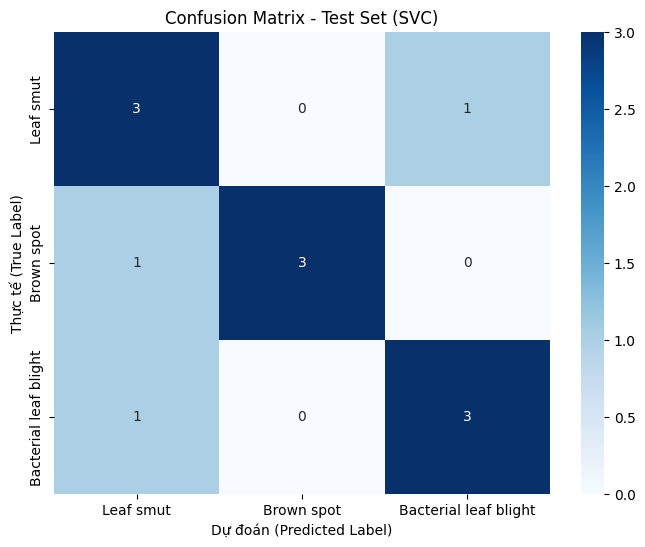

In [ ]:
from sklearn.svm import SVC

print("\n" + "="*40)
print(">>> HUẤN LUYỆN SVC (kernel='linear', C=10)")
print("="*40)

# Assuming X_train_scaled, y_train_labels, X_val_scaled, y_val_labels, X_test_scaled, y_test_labels
# and class_names are already defined from previous cells.

# 1. Initialize and train SVC model
svc_model = SVC(kernel='linear', C=10, probability=True, random_state=42)
print("Bắt đầu huấn luyện mô hình SVC...")
svc_model.fit(X_train, y_train)
print("Huấn luyện SVC hoàn tất!")

# 2. Evaluate the model
print("\n>>> Đánh giá hiệu suất mô hình:")

def evaluate_model(model, X_scaled, y_true, dataset_name):
    y_pred = model.predict(X_scaled)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n=== {dataset_name} Performance ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nClassification Report for {dataset_name}:\n{classification_report(y_true, y_pred, target_names=class_names)}")
    return y_pred

# Evaluate on Validation set
y_val_pred_svc = evaluate_model(svc_model, X_val, y_val, "Validation (SVC)")

# Evaluate on Test set
y_test_pred_svc = evaluate_model(svc_model, X_test, y_test, "Test (SVC)")

# Display Confusion Matrix for Test set
print("\n>>> Ma trận nhầm lẫn (Confusion Matrix) trên tập Test (SVC):")
cm_svc = confusion_matrix(y_test, y_test_pred_svc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Confusion Matrix - Test Set (SVC)')
plt.show()

### ===== Cell 9: KNN =====



>>> HUẤN LUYỆN K-NEAREST NEIGHBORS (n_neighbors=3)
Bắt đầu huấn luyện mô hình KNN...
Huấn luyện KNN hoàn tất!

>>> Đánh giá hiệu suất mô hình:

=== Validation (KNN) Performance ===
Accuracy:  0.5455
Precision: 0.5606
Recall:    0.5455
F1-Score:  0.5108

Classification Report for Validation (KNN):
                       precision    recall  f1-score   support

            Leaf smut       0.50      1.00      0.67         3
           Brown spot       0.50      0.25      0.33         4
Bacterial leaf blight       0.67      0.50      0.57         4

             accuracy                           0.55        11
            macro avg       0.56      0.58      0.52        11
         weighted avg       0.56      0.55      0.51        11


=== Test (KNN) Performance ===
Accuracy:  0.6667
Precision: 0.6722
Recall:    0.6667
F1-Score:  0.6627

Classification Report for Test (KNN):
                       precision    recall  f1-score   support

            Leaf smut       0.67      0.50      0.

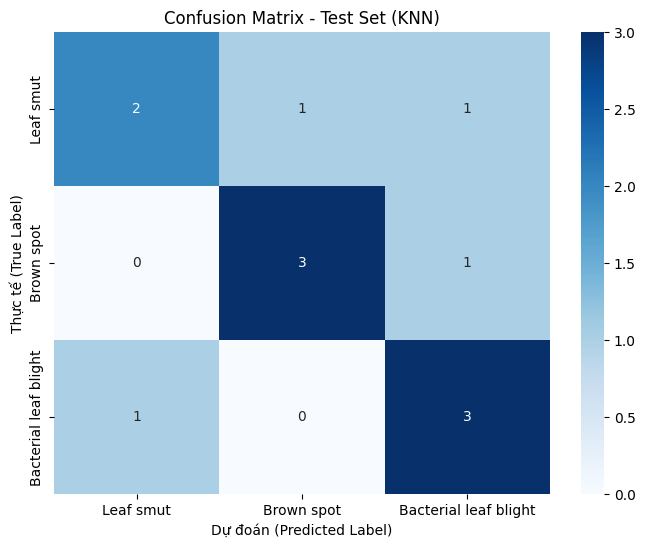

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("\n" + "="*40)
print(">>> HUẤN LUYỆN K-NEAREST NEIGHBORS (n_neighbors=3)")
print("="*40)

# 1. Initialize and train KNeighborsClassifier model
knn_model = KNeighborsClassifier(n_neighbors=3)
print("Bắt đầu huấn luyện mô hình KNN...")
knn_model.fit(X_train, y_train)
print("Huấn luyện KNN hoàn tất!")

# 2. Evaluate the model
print("\n>>> Đánh giá hiệu suất mô hình:")

# Evaluate on Validation set
y_val_pred_knn = evaluate_model(knn_model, X_val, y_val, "Validation (KNN)")

# Evaluate on Test set
y_test_pred_knn = evaluate_model(knn_model, X_test, y_test, "Test (KNN)")

# Display Confusion Matrix for Test set
print("\n>>> Ma trận nhầm lẫn (Confusion Matrix) trên tập Test (KNN):")
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Confusion Matrix - Test Set (KNN)')
plt.show()

### ===== Cell 10: RandomForest =====



>>> HUẤN LUYỆN RANDOM FOREST (random_state=42)
Bắt đầu huấn luyện mô hình Random Forest...
Huấn luyện Random Forest hoàn tất!

>>> Đánh giá hiệu suất mô hình:

=== Validation (Random Forest) Performance ===
Accuracy:  0.8182
Precision: 0.8909
Recall:    0.8182
F1-Score:  0.8106

Classification Report for Validation (Random Forest):
                       precision    recall  f1-score   support

            Leaf smut       0.60      1.00      0.75         3
           Brown spot       1.00      0.50      0.67         4
Bacterial leaf blight       1.00      1.00      1.00         4

             accuracy                           0.82        11
            macro avg       0.87      0.83      0.81        11
         weighted avg       0.89      0.82      0.81        11


=== Test (Random Forest) Performance ===
Accuracy:  0.7500
Precision: 0.7500
Recall:    0.7500
F1-Score:  0.7500

Classification Report for Test (Random Forest):
                       precision    recall  f1-score   sup

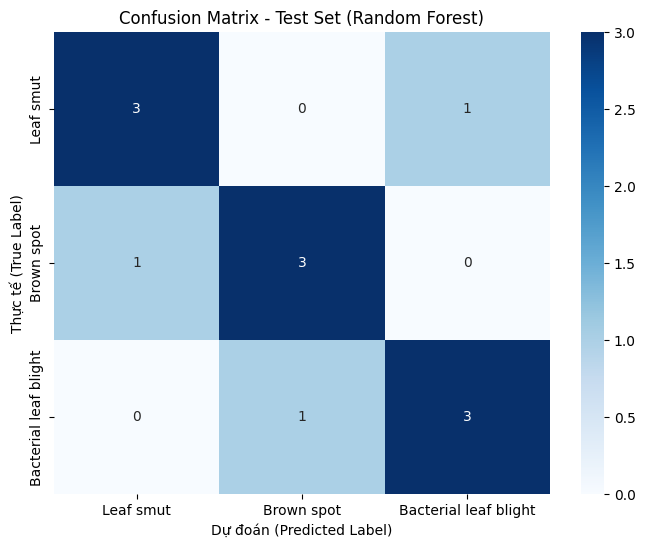

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*40)
print(">>> HUẤN LUYỆN RANDOM FOREST (random_state=42)")
print("="*40)

# 1. Initialize and train RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)
print("Bắt đầu huấn luyện mô hình Random Forest...")
rf_model.fit(X_train, y_train)
print("Huấn luyện Random Forest hoàn tất!")

# 2. Evaluate the model
print("\n>>> Đánh giá hiệu suất mô hình:")

# Evaluate on Validation set
y_val_pred_rf = evaluate_model(rf_model, X_val, y_val, "Validation (Random Forest)")

# Evaluate on Test set
y_test_pred_rf = evaluate_model(rf_model, X_test, y_test, "Test (Random Forest)")

# Display Confusion Matrix for Test set
print("\n>>> Ma trận nhầm lẫn (Confusion Matrix) trên tập Test (Random Forest):")
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Confusion Matrix - Test Set (Random Forest)')
plt.show()

### ===== Cell 11: Naive Bayes =====



>>> HUẤN LUYỆN NAIVE BAYES (GaussianNB)
Bắt đầu huấn luyện mô hình Naive Bayes...
Huấn luyện Naive Bayes hoàn tất!

>>> Đánh giá hiệu suất mô hình:

=== Validation (Naive Bayes) Performance ===
Accuracy:  0.3636
Precision: 0.1455
Recall:    0.3636
F1-Score:  0.2078

Classification Report for Validation (Naive Bayes):
                       precision    recall  f1-score   support

            Leaf smut       0.00      0.00      0.00         3
           Brown spot       0.00      0.00      0.00         4
Bacterial leaf blight       0.40      1.00      0.57         4

             accuracy                           0.36        11
            macro avg       0.13      0.33      0.19        11
         weighted avg       0.15      0.36      0.21        11


=== Test (Naive Bayes) Performance ===
Accuracy:  0.3333
Precision: 0.1212
Recall:    0.3333
F1-Score:  0.1778

Classification Report for Test (Naive Bayes):
                       precision    recall  f1-score   support

            L

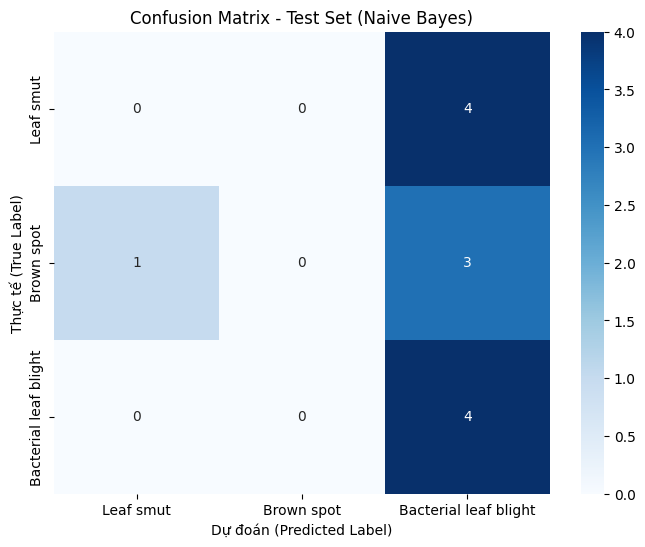

In [ ]:
from sklearn.naive_bayes import GaussianNB

print("\n" + "="*40)
print(">>> HUẤN LUYỆN NAIVE BAYES (GaussianNB)")
print("="*40)

# --- FIX: Ensure X_train, y_train, evaluate_model, and class_names are defined ---
# If you encounter a 'NameError', please ensure you have run all preceding cells
# (especially 'Cell 8: Chia mẫu Train/Test' and 'Cell 9: SVC')
# to load and preprocess data, and define the evaluation function and class names.
# --------------------------------------------------------------------------------

# 1. Initialize and train GaussianNB model
nb_model = GaussianNB()
print("Bắt đầu huấn luyện mô hình Naive Bayes...")
nb_model.fit(X_train, y_train)
print("Huấn luyện Naive Bayes hoàn tất!")

# 2. Evaluate the model
print("\n>>> Đánh giá hiệu suất mô hình:")

# Evaluate on Validation set
y_val_pred_nb = evaluate_model(nb_model, X_val, y_val, "Validation (Naive Bayes)")

# Evaluate on Test set
y_test_pred_nb = evaluate_model(nb_model, X_test, y_test, "Test (Naive Bayes)")

# Display Confusion Matrix for Test set
print("\n>>> Ma trận nhầm lẫn (Confusion Matrix) trên tập Test (Naive Bayes):")
cm_nb = confusion_matrix(y_test, y_test_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Confusion Matrix - Test Set (Naive Bayes)')
plt.show()

### ===== Cell 12: Decision Tree =====



>>> HUẤN LUYỆN DECISION TREE (random_state=42)
Bắt đầu huấn luyện mô hình Decision Tree...
Huấn luyện Decision Tree hoàn tất!

>>> Đánh giá hiệu suất mô hình:

=== Validation (Decision Tree) Performance ===
Accuracy:  0.7273
Precision: 0.7909
Recall:    0.7273
F1-Score:  0.7215

Classification Report for Validation (Decision Tree):
                       precision    recall  f1-score   support

            Leaf smut       0.50      0.67      0.57         3
           Brown spot       1.00      0.50      0.67         4
Bacterial leaf blight       0.80      1.00      0.89         4

             accuracy                           0.73        11
            macro avg       0.77      0.72      0.71        11
         weighted avg       0.79      0.73      0.72        11


=== Test (Decision Tree) Performance ===
Accuracy:  0.6667
Precision: 0.7500
Recall:    0.6667
F1-Score:  0.6722

Classification Report for Test (Decision Tree):
                       precision    recall  f1-score   sup

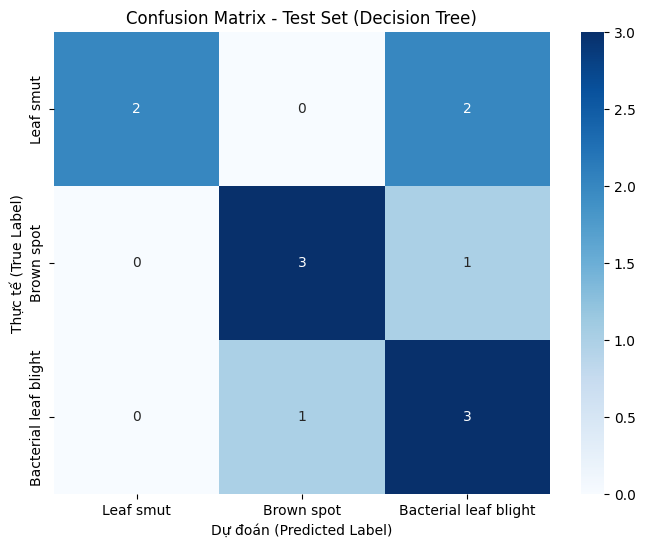

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("\n" + "="*40)
print(">>> HUẤN LUYỆN DECISION TREE (random_state=42)")
print("="*40)

# 1. Initialize and train DecisionTreeClassifier model
dt_model = DecisionTreeClassifier(random_state=42)
print("Bắt đầu huấn luyện mô hình Decision Tree...")
dt_model.fit(X_train, y_train)
print("Huấn luyện Decision Tree hoàn tất!")

# 2. Evaluate the model
print("\n>>> Đánh giá hiệu suất mô hình:")

# Evaluate on Validation set
y_val_pred_dt = evaluate_model(dt_model, X_val, y_val, "Validation (Decision Tree)")

# Evaluate on Test set
y_test_pred_dt = evaluate_model(dt_model, X_test, y_test, "Test (Decision Tree)")

# Display Confusion Matrix for Test set
print("\n>>> Ma trận nhầm lẫn (Confusion Matrix) trên tập Test (Decision Tree):")
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Confusion Matrix - Test Set (Decision Tree)')
plt.show()

### ===== Cell 13: ROC curve =====


y_test_onehot and n_classes re-initialized.
>>> Generating and plotting ROC curves for each model again...


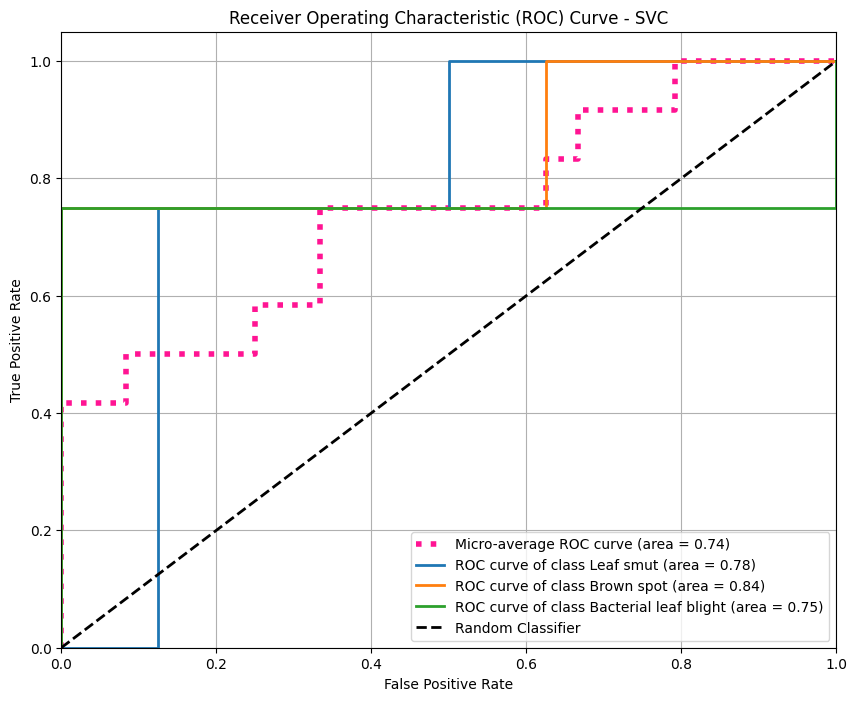

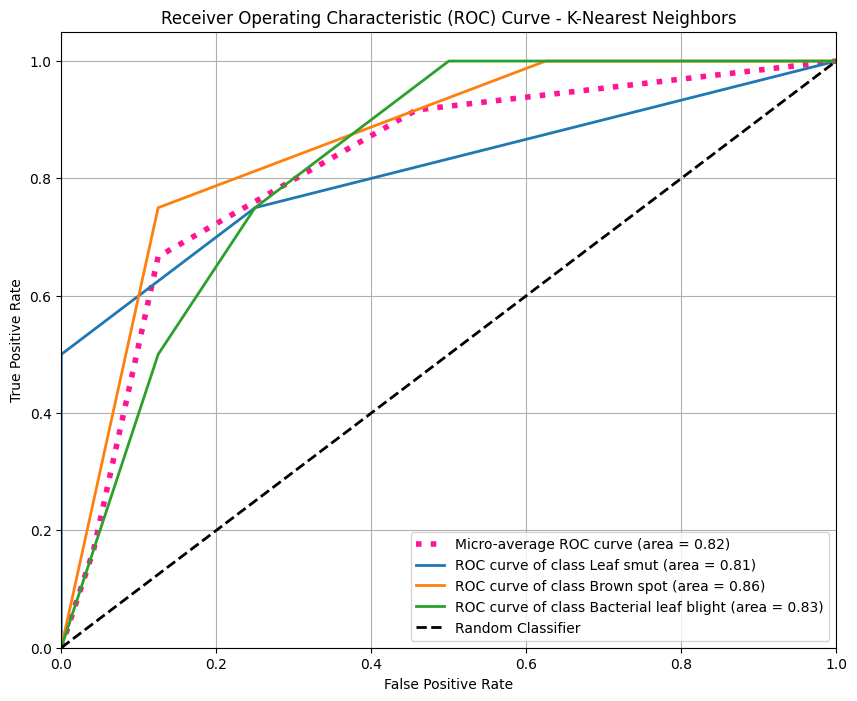

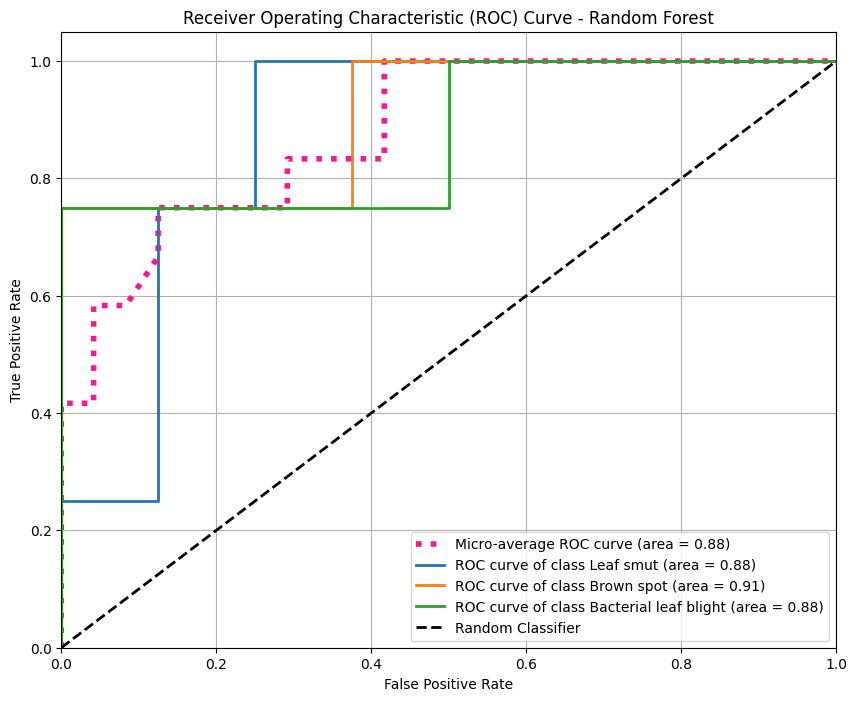

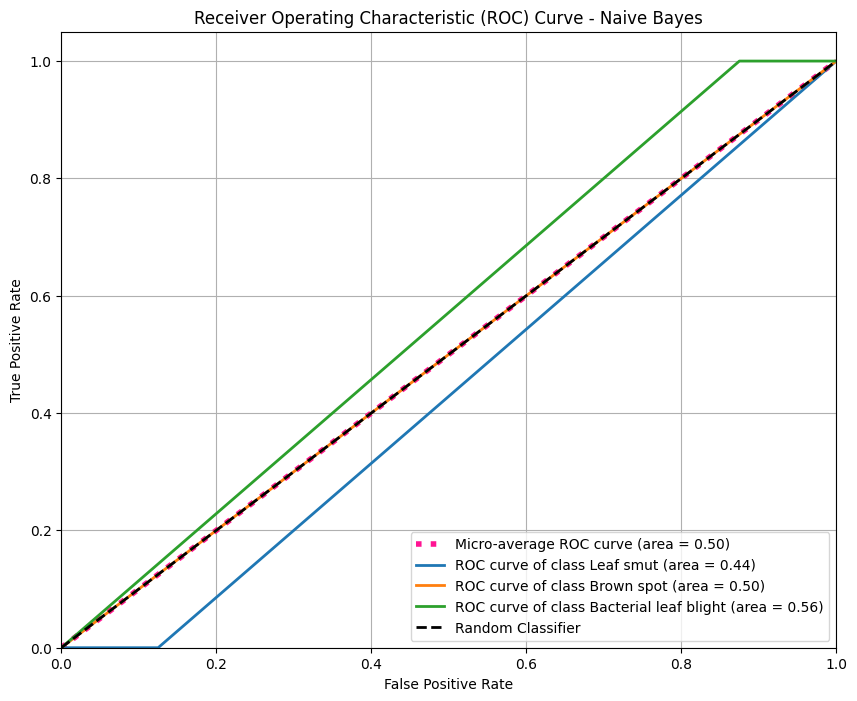

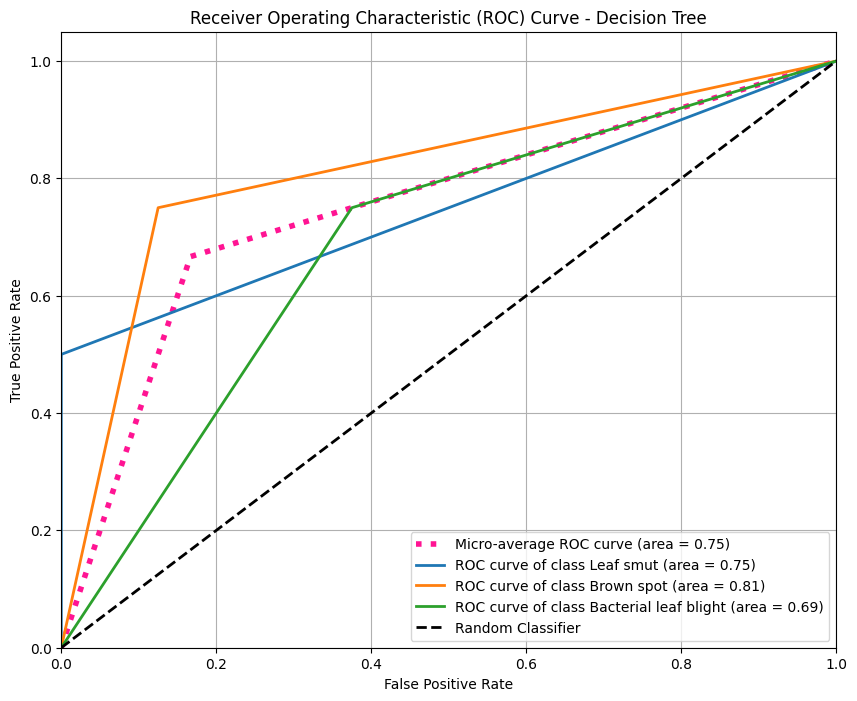

>>> All ROC curves regenerated and plotted.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Re-ensure these are defined, in case previous runs were partial
# 1. One-hot encode y_test (if not already done)
if 'y_test_onehot' not in locals():
    y_test_reshaped = y_test.reshape(-1, 1)
    onehot_encoder = OneHotEncoder(sparse_output=False, categories='auto')
    y_test_onehot = onehot_encoder.fit_transform(y_test_reshaped)
    n_classes = y_test_onehot.shape[1]
    print("y_test_onehot and n_classes re-initialized.")
else:
    print("y_test_onehot and n_classes are already defined.")

# 2. Create a list of models and their names (assuming models are already trained)
models = [
    (svc_model, "SVC"),
    (knn_model, "K-Nearest Neighbors"),
    (rf_model, "Random Forest"),
    (nb_model, "Naive Bayes"),
    (dt_model, "Decision Tree")
]

print(">>> Generating and plotting ROC curves for each model again...")

for model, name in models:
    if not hasattr(model, 'predict_proba'):
        print(f"Skipping {name}: model does not have 'predict_proba' method.")
        continue

    y_score = model.predict_proba(X_test)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_onehot[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_onehot.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'Đường cong ROC của class {class_names[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Đường cong ROC của - {name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

print(">>> All ROC curves regenerated and plotted.")